<a href="https://colab.research.google.com/github/SoyOrnella/telecomx2/blob/main/TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [26]:
import pandas as pd

try:
    # Carga el archivo JSON localmente
    df = pd.read_json('/content/TelecomX_Data.json')
    print("Datos cargados con éxito desde TelecomX_Data.json:")
    print(df.head())

except FileNotFoundError:
    print("Error: El archivo 'TelecomX_Data.json' no se encontró. Asegúrate de que esté en el directorio '/content/'.")
except pd.errors.EmptyDataError:
    print("Error: El archivo 'TelecomX_Data.json' está vacío.")
except Exception as e:
    print(f"Ha ocurrido un error inesperado al cargar el archivo JSON: {e}")


Datos cargados con éxito desde TelecomX_Data.json:
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'Intern

In [27]:
print("Explorando las columnas anidadas 'customer' y 'phone':")
display(df[['customer', 'phone']].head())

print("\nTipo de dato de la columna 'customer' (es un diccionario):", type(df['customer'].iloc[0]))

print("\nPara aplanar estas columnas, recuerda que puedes ejecutar la celda `bsm-WTLjmHvt` bajo '🔧 Transformación'.")

Explorando las columnas anidadas 'customer' y 'phone':


,customer,phone
0,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
1,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}"
2,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
3,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
4,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}"



Tipo de dato de la columna 'customer' (es un diccionario): <class 'dict'>

Para aplanar estas columnas, recuerda que puedes ejecutar la celda `bsm-WTLjmHvt` bajo '🔧 Transformación'.


### Separación de Variables de Entrada (X) y Salida (y)

Para el modelado de Machine Learning, es fundamental separar el conjunto de datos en variables predictoras (X) y la variable objetivo (y). En este caso, 'Churn' es nuestra variable objetivo, y el resto de las columnas (excluyendo 'customerID' que es solo un identificador) serán nuestras características de entrada.

In [38]:
# Separar la variable objetivo (y) y las características (X)
X = df.drop(['Churn'], axis=1)
y = df['Churn']

print("Dimensiones de X (Características):")
print(X.shape)
print("Primeras 5 filas de X:")
display(X.head())

print("Dimensiones de y (Variable Objetivo):")
print(y.shape)
print("Primeras 5 filas de y:")
display(y.head())

Dimensiones de X (Características):
(7043, 7072)
Primeras 5 filas de X:


,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,False,False,True,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,False,False,True,False,False,...,False,True,False,False,False,False,True,False,False,True


Dimensiones de y (Variable Objetivo):
(7043,)
Primeras 5 filas de y:


,Churn
0,0
1,0
2,1
3,1
4,1


### División de Datos en Conjuntos de Entrenamiento y Prueba

Dividiremos el conjunto de datos en dos subconjuntos: uno para entrenar el modelo (entrenamiento) y otro para evaluar su rendimiento (prueba). Usaremos un 80% de los datos para entrenamiento y un 20% para prueba, asegurando que la distribución de la variable objetivo 'Churn' sea similar en ambos conjuntos (`stratify=y`).

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

print("\nDistribución de 'Churn' en y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribución de 'Churn' en y_test:")
print(y_test.value_counts(normalize=True))

Dimensiones de X_train: (5634, 7072)
Dimensiones de X_test: (1409, 7072)
Dimensiones de y_train: (5634,)
Dimensiones de y_test: (1409,)

Distribución de 'Churn' en y_train:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Distribución de 'Churn' en y_test:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


#🔧 Transformación

In [29]:
# Función para aplanar columnas anidadas
def flatten_json_column(df, column_name):
    # Convierte la columna de diccionarios en un DataFrame
    flattened_df = pd.json_normalize(df[column_name])
    # Renombra las columnas aplanadas para evitar conflictos y claridad
    flattened_df.columns = [f"{column_name}_{subcol}" for subcol in flattened_df.columns]
    # Elimina la columna original anidada y concatena las nuevas columnas
    df = pd.concat([df.drop(columns=[column_name]), flattened_df], axis=1)
    return df

# Lista de columnas a aplanar
columns_to_flatten = ['customer', 'phone', 'internet', 'account']

# Aplana cada columna en la lista
for col in columns_to_flatten:
    df = flatten_json_column(df, col)

print("DataFrame después de aplanar las columnas anidadas:")
print(df.head())

# Verificar las columnas resultantes
print("\nNuevas columnas del DataFrame:")
print(df.columns.tolist())


DataFrame después de aplanar las columnas anidadas:
   customerID Churn customer_gender  customer_SeniorCitizen customer_Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer_Dependents  customer_tenure phone_PhoneService phone_MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes     

#📊 Carga y análisis

In [30]:
print("Información general del DataFrame:")
df.info()

print("\nTipos de datos de cada columna:")
print(df.dtypes)

# Identificar y convertir 'account_Charges.Total' a numérico
# Primero, veamos los valores únicos en 'account_Charges.Total' que no son numéricos.
# Estos suelen ser espacios en blanco o cadenas como ' '.
# Luego, los convertimos a NaN y finalmente a float.

# Reemplazar valores no numéricos (como espacios en blanco) con NaN y luego convertir a float
df['account_Charges.Total'] = pd.to_numeric(df['account_Charges.Total'], errors='coerce')

# Llenar los valores NaN resultantes (que podrían ser de los espacios en blanco originales)
# con 0, asumiendo que un valor total no registrado significa 0 cargos.
df['account_Charges.Total'] = df['account_Charges.Total'].fillna(0)

# Eliminar filas donde 'Churn' es una cadena vacía
initial_rows = df.shape[0]
df = df[df['Churn'] != ''].copy()
print(f"\nSe eliminaron {initial_rows - df.shape[0]} filas con valores vacíos en la columna 'Churn'.")

print("\nValores nulos por columna (después de la conversión de TotalCharges y limpieza de Churn):")
print(df.isnull().sum())

print("\nTipos de datos de cada columna (después de la conversión de TotalCharges y limpieza de Churn):")
print(df.dtypes)

print("\nNúmero de valores únicos por columna (primeras 50 columnas si hay muchas):")
print(df.nunique().head(50))


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_Tech

### Codificación de la Variable Objetivo 'Churn'

Convertiremos la columna 'Churn' a un formato numérico ('Yes' a 1 y 'No' a 0). Esto es crucial para los modelos de aprendizaje automático, ya que la mayoría requieren que la variable objetivo sea numérica.

In [31]:
# Codificar la columna 'Churn' a valores numéricos
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("DataFrame después de codificar 'Churn':")
display(df[['Churn']].head())

print("Valores únicos en la columna 'Churn' después de la codificación:")
print(df['Churn'].value_counts())

DataFrame después de codificar 'Churn':


,Churn
0,0
1,0
2,1
3,1
4,1


Valores únicos en la columna 'Churn' después de la codificación:
Churn
0    5174
1    1869
Name: count, dtype: int64


### One-Hot Encoding de Variables Categóricas

Ahora, aplicaremos `pd.get_dummies` para convertir el resto de las variables categóricas en un formato numérico (one-hot encoding). Esto es esencial para muchos algoritmos de Machine Learning. `drop_first=True` se utiliza para evitar la multicolinealidad, eliminando la primera categoría de cada variable y reduciendo el número de características.

In [32]:
df = pd.get_dummies(df, drop_first=True)

print("DataFrame después de aplicar One-Hot Encoding:")
display(df.head())

print("Nuevas columnas del DataFrame después de One-Hot Encoding:")
print(df.columns.tolist())

DataFrame después de aplicar One-Hot Encoding:


,Churn,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,False,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,True


Nuevas columnas del DataFrame después de One-Hot Encoding:
['Churn', 'customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customer

### Separación de Variables de Entrada (X) y Salida (y)

Finalmente, dividiremos el DataFrame en características de entrada (X) y la variable objetivo (y). La variable objetivo será 'Churn', y el resto de las columnas (excluyendo 'customerID' que es solo un identificador) serán las características que usaremos para predecir 'Churn'.

#📄Informe final


Análisis de la columna 'Churn':
Churn
0    5174
1    1869
Name: count, dtype: int64

Porcentaje de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_723/1267577567.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


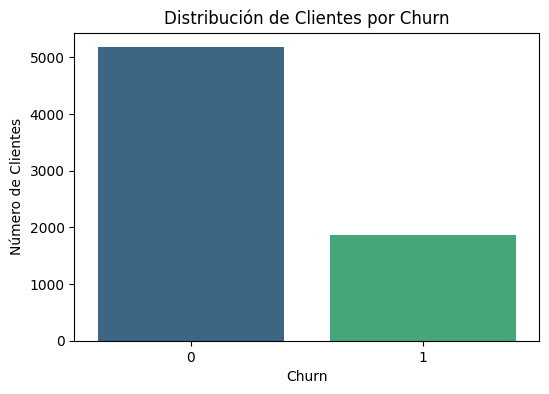


Estadísticas de account_Charges.Monthly y account_Charges.Total por Churn:
       account_Charges.Monthly  account_Charges.Total
Churn                                                
0                    61.265124            2549.911442
1                    74.441332            1531.796094


/tmp/ipykernel_723/1267577567.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges.Monthly', data=df, palette='plasma')
/tmp/ipykernel_723/1267577567.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges.Total', data=df, palette='plasma')


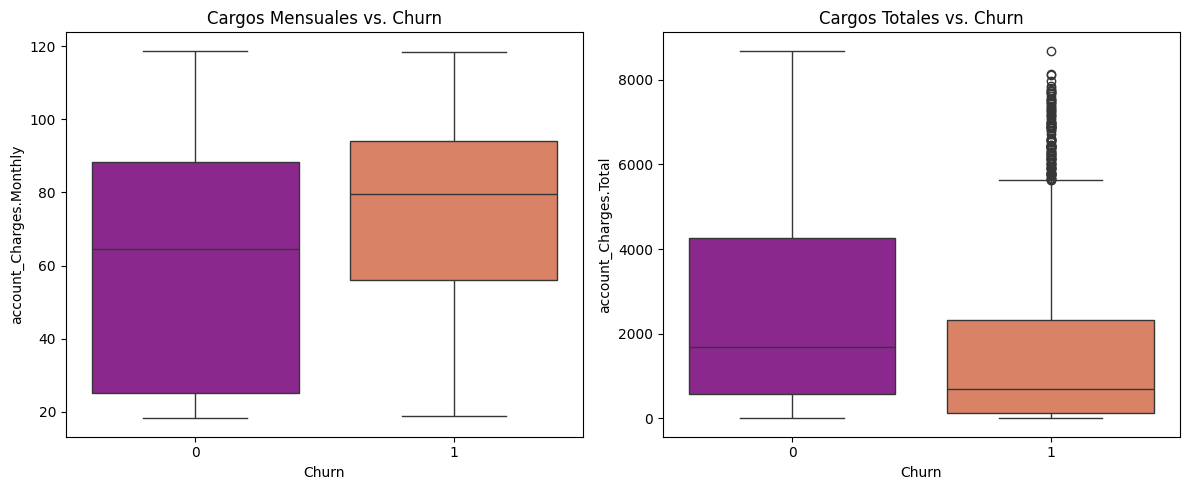

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de la columna 'Churn'
print("\nAnálisis de la columna 'Churn':")
print(df['Churn'].value_counts())
print("\nPorcentaje de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualización de la distribución de Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')
plt.show()

# Ahora que 'account_Charges.Total' es numérico, podemos analizarlo con Churn
print("\nEstadísticas de account_Charges.Monthly y account_Charges.Total por Churn:")
print(df.groupby('Churn')[['account_Charges.Monthly', 'account_Charges.Total']].mean())

# Visualización de la relación entre Charges y Churn
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='account_Charges.Monthly', data=df, palette='plasma')
plt.title('Cargos Mensuales vs. Churn')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='account_Charges.Total', data=df, palette='plasma')
plt.title('Cargos Totales vs. Churn')
plt.tight_layout()
plt.show()


In [21]:
try:
    print("DataFrame 'df' está definido. Primeras 5 filas:")
    display(df.head())
    print("Tipo de 'df':", type(df))
except NameError:
    print("Error: DataFrame 'df' no está definido.")

DataFrame 'df' está definido. Primeras 5 filas:
Error: DataFrame 'df' no está definido.
